# Machine Translation Project: Russian to English (Biomedical Domain)

This Jupyter Notebook serves as an **organized workflow** for training and evaluating a **Neural Machine Translation (NMT) model** using **Sequence-to-Sequence with Attention**.

In [ ]:
# Clone repo from github
#!git clone https://fboglind@github.com/fboglind/lab4_mt_project.git

In [ ]:
# Paperspace Gradient specific code
import os

# Set base directory
base_dir = "/notebooks/lab4_mt_project"
os.chdir(base_dir)

# Verify that the directory change was successful
print("Current working directory:", os.getcwd())

Current working directory: /notebooks/lab4_mt_project


In [ ]:
# Install dependencies (if not installed)
%pip install torch pandas matplotlib seaborn sentencepiece sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.2 MB/s eta 0:00:00


## **1. Create parallel corpus and test set**
- Reads files containing abstracts
- Creates a parallel corpus
- Creates a test set

The data for this project consists of parallel abstracts which can be retrieved from Medline using a script: wmtbio22_train_data.py.
Biopython and a valid email is needed to access the data in Medline.
https://github.com/biomedical-translation-corpora/corpora/blob/master/wmtbio22_train_data.py

In [ ]:
# Assuming that the Medline data has been downloaded and extracted to abstracts/ we create parallel corpus and test set
%mkdir -p data
!python3 scripts/preprocess_wmt22.py

## **2. Load & Explore Data**


- Load the parallel corpus
- Analyze text length distributions
- Check for alignment issues
- Clean the data

                                                  Russian  \
count                                               11152   
unique                                              11150   
top     Проанализировано качество оказания помощи паци...   
freq                                                    2   

                                                  English  
count                                               11152  
unique                                              11144  
top     The aim of the study was to elaborate lingual ...  
freq                                                    2  
                                             Russian  \
0  Резюме Цель: Определить, в какой степени грипп...   
1  Резюме Цель: Провести экспертную процедуру опр...   
2  Резюме Цель: Определить влияние еженедельной н...   
3  Резюме Цель: Определить, явилась ли политика б...   
4  Резюме Цель: Оценить проблему туберкулеза со м...   

                                             English  
0 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


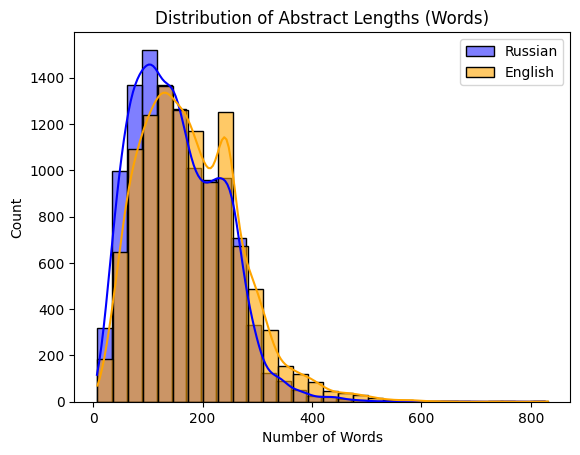

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/parallel_corpus.tsv", sep="\t", encoding="utf-8")

# Basic statistics
print(df.describe())
print(df.head())

# Plot text length distributions
df["Russian_Length"] = df["Russian"].apply(lambda x: len(x.split()))
df["English_Length"] = df["English"].apply(lambda x: len(x.split()))

sns.histplot(df["Russian_Length"], bins=30, kde=True, label="Russian", color="blue")
sns.histplot(df["English_Length"], bins=30, kde=True, label="English", color="orange", alpha=0.6)
plt.legend()
plt.title("Distribution of Abstract Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

Let's remove some of the 'misaligned' abstracts, while also perform some basic cleaning

In [11]:
!python3 scripts/clean_parallel_corpus.py --input data/parallel_corpus.tsv --output data/cleaned_parallel_corpus_initial.tsv

Cleaned parallel corpus saved to data/cleaned_parallel_corpus_initial.tsv


In [111]:
# Check the cleaned data
df = pd.read_csv("data/cleaned_parallel_corpus_initial.tsv", sep="\t", encoding="utf-8")
# Display one column per row for the first lines of the dataframe
for index, row in df.head(10).iterrows():
    print(f"Row {index}:")
    print(f"Russian: {row['Russian']}")
    print(f"English: {row['English']}")
    print(f"Russian_Length: {row['Russian_Length']}")
    print(f"English_Length: {row['English_Length']}")
    print("-" * 50)

Row 0:
Russian: Резюме Цель: Определить, в какой степени грипп способствует заражению лиц всех возрастов в Бангладеш тяжелой острой респираторной инфекцией (ТОРИ), которая является основной причиной детской смертности. Методы: Врачами были взяты мазки из носа и зева для анализа на вирус гриппа у пациентов, которые были госпитализированы в течение семи дней от начала заболевания тяжелой острой респираторной инфекцией (ТОРИ) или консультировались у врача в амбулаторном режиме по поводу гриппоподобной болезни (ГПБ). Было проведено исследование пользования медико-санитарной помощью на уровне общин для определения доли жителей участка, обслуживаемого больницей, которые обращались за помощью в обследуемые медицинские учреждения, и расчета заболеваемости гриппом с использованием указанного показателя в качестве знаменателя. Результаты: Оценочные показатели заболеваемости ТОРИ, коррелируемой с гриппом, у детей в возрасте до 5 лет, составили 6,7 (95% доверительный интервал, ДИ: 0-18,3); 4,4 (95

Just by looking at the first lines we can see that the Russian text contain some reocurring opening phrases that have no counterpart in the English text. 

We scan the text for such common opening phrases while also checking if they have any corresponding English phrases:

In [12]:
!python3 scripts/extract_openers_from_english.py


🔹 Russian Opener: ^Цель исследования  (Count: 2402)
   to study the                             264
   the objective of                         200
   to evaluate the                          161
   the aim of                               133
   to assess the                            91
   to investigate the                       85
   to analyze the                           68
   to determine the                         66
   the purpose of                           58
   to estimate the                          43

🔹 Russian Opener: ^Цель работы  (Count: 268)
   the objective of                         133
   the purpose of                           30
   the aim of                               24
   to study the                             5
   the study was                            4
   to evaluate the                          4
   to improve the                           3
   to analyze the                           3
   to assess the                            3
   aim of

Let's remove these opening phrases from the Russian texts together with common headers (ex. "Результаты и обсуждение" - "Results and discussion" etc.) as these are not present in the English text either.

In [13]:
!python3 scripts/clean_russian_openers.py
!head data/cleaned_parallel_corpus.tsv

Cleaned file saved to: data/cleaned_parallel_corpus.tsv
Russian	English	Russian_Length	English_Length	Length_Ratio
Определить, в какой степени грипп способствует заражению лиц всех возрастов в Бангладеш тяжелой острой респираторной инфекцией (ТОРИ), которая является основной причиной детской смертности. Методы: Врачами были взяты мазки из носа и зева для анализа на вирус гриппа у пациентов, которые были госпитализированы в течение семи дней от начала заболевания тяжелой острой респираторной инфекцией (ТОРИ) или консультировались у врача в амбулаторном режиме по поводу гриппоподобной болезни (ГПБ). Было проведено исследование пользования медико-санитарной помощью на уровне общин для определения доли жителей участка, обслуживаемого больницей, которые обращались за помощью в обследуемые медицинские учреждения, и расчета заболеваемости гриппом с использованием указанного показателя в качестве знаменателя.  Оценочные показатели заболеваемости ТОРИ, коррелируемой с гриппом, у детей в возраст

The abstracts are quite long, we therefore split them into sentences before further tokenization.

In [14]:
!python3 scripts/split_abstracts.py --input data/cleaned_parallel_corpus.tsv --output data/sentence_aligned_corpus.tsv

Sentence-aligned corpus saved to data/sentence_aligned_corpus.tsv


In [6]:
# We split the test into sentences as well
!python3 scripts/split_single_column.py \
  --input data/test_raw_ru.txt \
  --output data/test_sentence_set.txt

In [ ]:
# Check for misaligned sentences
import pandas as pd
df = pd.read_csv("data/sentence_aligned_corpus.tsv", sep="\t", encoding="utf-8")

# Check for misaligned rows
misaligned = df[(df["Russian"].str.len() < 10) | (df["English"].str.len() < 10)]
print(f"⚠️ Found {len(misaligned)} potentially broken rows.")

# Check for newline artifacts
newline_issues = df[df["Russian"].str.contains("\n") | df["English"].str.contains("\n")]
print(f" Found {len(newline_issues)} rows with embedded newlines.")


⚠️ Found 0 potentially broken rows.
🔍 Found 0 rows with embedded newlines.


Let's scan the Russian text for Latin terms

In [16]:
import re

def contains_latin(text):
    return bool(re.search(r"[A-Za-z]{2,}", text))




# Filter or flag those rows
df_with_latin = df[df["Russian"].apply(contains_latin)]
print(f"Found {len(df_with_latin)} rows with Latin characters in Russian.")

for i, row in df.iterrows():
    if contains_latin(row["Russian"]):
        print(f"[{i}] {row['Russian']}")


Found 4624 rows with Latin characters in Russian.
[1] Провести экспертную процедуру определения научно-исследовательских приоритетов в области сексуального и репродуктивного здоровья подростков в странах с низким и средним уровнем доходов. Методы: Авторы изменили метод определения приоритетов Инициативы по исследованиям детского здоровья и питания (CHNRI) для получения информации приблизительно от 300 исследователей, доноров и руководителей программ здравоохранения, обладающих обширными знаниями и опытом, со всех географических регионов мира. В ходе трехступенчатой процедуры экспертов просили: (i) оценить целевые области по степени важности; (ii) сформулировать исследовательские вопросы по каждой области и (iii) расставить сформулированные вопросы в порядке приоритетности.  Семь важных областей сексуального и репродуктивного здоровья подростков были определены как важные: (i) материнское здоровье; (ii) контрацепция; (iii) гендерное насилие; (iv) лечение и уход за пациентами с вирусом и

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [17]:
!python3 scripts/extract_numbers_and_latin.py

Top Latin-script terms:
sub                  1038
sup                  758
II                   460
III                  362
COVID-19             320
in                   198
IV                   192
D-                   133
CD4                  102
MMSE                 100
of                   99
Ki-67                99
vitro                94
PubMed               91
NIHSS                91
VEGF                 91
PANSS                89
I-II                 82
pylori               81
SF-36                76
BDNF                 75
TNF-                 71
VEGF-                71
S100                 66
IL-6                 64
IgG                  64
Grade                63
II-III               62
ROC-                 62
vivo                 60
L-                   60
p0                   59
ii                   56
OR                   54
spp                  53
HER2                 53
SARS-CoV-2           53
Wistar               52
IL-                  51
iii                  50
HbA1 

## **3. Preprocessing: SentencePiece Tokenization**

- Extract source language data
- Train a SentencePiece model
- Tokenize the training and test sets

In [20]:
import sentencepiece as spm

# Train SentencePiece. Output: spm_ru_en.model, spm_ru_en.vocab
!mkdir -p models
!python3 scripts/sentencepiece_train.py

Loaded 4967 user-defined symbols
sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/sentence_aligned_corpus.tsv
  input_format: 
  model_prefix: models/spm_ru_en
  model_type: UNIGRAM
  vocab_size: 34967
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: sub
  user_defined_symbols: sup
  user_defined_symbols: II
  user_defined_symbols: III
  user_defined_symbols: COVID-19
  user_defined_symbols: in
  user_defined_symbols: IV
  user_defined_symbols: D-
  user_defined_symbols: CD4
  user_defined_symbols: MMSE
  user_defined

In [21]:
!head -n20 models/spm_ru_en.vocab

<unk>	0
<s>	0
</s>	0
sub	0
sup	0
II	0
III	0
COVID-19	0
in	0
IV	0
D-	0
CD4	0
MMSE	0
of	0
Ki-67	0
vitro	0
PubMed	0
NIHSS	0
VEGF	0
PANSS	0


In [23]:
# Apply SentencePiece Tokenization
!python3 scripts/apply_sentencepiece.py --input data/sentence_aligned_corpus.tsv --output data/spm_parallel_corpus.tsv --model models/spm_ru_en.model --to_parallel

Tokenizing PARALLEL columns...
SentencePiece tokenization complete. Processed 11007 sentences. Saved to data/spm_parallel_corpus.tsv


In [24]:
!head -n 5 data/spm_parallel_corpus.tsv

Russian	English	Russian_Length	English_Length	Length_Ratio
▁Определить , ▁в ▁как ой ▁степени ▁грипп ▁способству ет ▁за р ажен ию ▁лиц ▁всех ▁возрастов ▁в ▁Б англ а де ш ▁тяжелой ▁острой ▁респираторн ой ▁ инфекцией ▁( Т ОРИ ), ▁которая ▁является ▁основной ▁причиной ▁детск ой ▁смертности . ▁Методы : ▁ Врач ами ▁были ▁взяты ▁ ма з ки ▁из ▁носа ▁и ▁ з ева ▁для ▁анализа ▁на ▁ вирус ▁гриппа ▁у ▁пациентов , ▁которые ▁были ▁ госпитализирован ы ▁в ▁течение ▁семи ▁дней ▁от ▁начала ▁заболевания ▁тяжелой ▁острой ▁респираторн ой ▁ инфекцией ▁( Т ОРИ ) ▁или ▁ ко нсульт ировали сь ▁у ▁врача ▁в ▁амбулаторн ом ▁режиме ▁по ▁по воду ▁грипп оподобн ой ▁болезни ▁( ГП Б ). ▁Был о ▁проведен о ▁исследование ▁ поль з ования ▁медико - санитарн ой ▁помощью ▁на ▁уровне ▁общ ин ▁для ▁определения ▁доли ▁жителей ▁участка , ▁об с луж ива емого ▁больнице й , ▁которые ▁обращались ▁за ▁помощью ▁в ▁обследуем ые ▁ медицинские ▁учреждения , ▁и ▁расчета ▁заболеваемости ▁грипп ом ▁с ▁использованием ▁указанн ого ▁показателя ▁

We must also tokenize the test set

In [13]:
# Apply sentencepiece to the test set
!python3 scripts/apply_sentencepiece.py \
  --input data/test_sentence_set.txt \
  --output data/preprocessed_test_set.tsv\
  --is_test_set

SentencePiece tokenization complete. Processed 50              TEST sentences. Saved to data/preprocessed_test_set.tsv


In [15]:
!head -n 5 data/preprocessed_test_set.tsv

▁Реализаци я ▁эффективной ▁меж с ек тор альной ▁политики ▁в ▁области ▁питания ▁оста ется ▁сложной ▁задачей , ▁актуальной ▁во ▁всем ▁мире . ▁Из уч ая ▁отчеты ▁с ов е щ а ний ▁и ▁консультаци й ▁Всемирн ой ▁организации ▁здравоохранения ▁( ВОЗ ), ▁с оз ы ваемых ▁для ▁политическ ого ▁руководства ▁ го с удар ст в - ч лен ов ▁региона ▁западн ой ▁части ▁Т их ого ▁ ок е ана , ▁авторы ▁со об щ или ▁ о ▁том , ▁как ▁лица , ▁определяющи е ▁национальн ую ▁политику , ▁ а ▁также ▁внешни е ▁субъект ы ▁могут ▁поддержива ть ▁различны е ▁уровн и ▁реализации ▁политики ▁в ▁области ▁питания . ▁Ключев ые ▁в ы вод ы ▁политическ ого ▁руководства , ▁участвующе го ▁в ▁с ов е щ а ния х ▁по ▁вопросам ▁про дов оль ст ви я ▁и ▁питания , ▁включают ▁в ▁себя ▁то , ▁что ▁реализаци я ▁политики ▁в ▁области ▁питания ▁на ▁уровне ▁стран ▁опира ется ▁на ▁четк ую ▁разработк у ▁политики , ▁ организационно е ▁планировани е ▁и ▁механизмы ▁управления , ▁которые ▁способствую т ▁коллективн ой ▁ответственности ▁во ▁многи х ▁сектор ах 

## **4. Model Training**

- Train the sequence-to-sequence model
- Use label smoothing to improve training stability
- Save the trained model

In [ ]:
# Train the model with accumulated gradients (batch size 8, gradient accumulation steps 4)
!python3 scripts/seq2seq_train.py \
  --batch-size 8 \
  --accum-steps 4


Loading training data from data/spm_parallel_corpus.tsv...
Loaded 11007 samples after dropping NaN values
Building vocabularies...
Vocabulary sizes: Source = 29850, Target = 13313
Training on: cuda
Training on: cuda
Training LSTM model
Starting training for 15 epochs...
  Batch 10 - Avg Loss: 9.3518
  Batch 20 - Avg Loss: 8.9214
  Batch 30 - Avg Loss: 8.3461
  Batch 40 - Avg Loss: 7.7533
  Batch 50 - Avg Loss: 7.3658
  Batch 60 - Avg Loss: 7.0614
  Batch 70 - Avg Loss: 6.8310
  Batch 80 - Avg Loss: 6.6322
  Batch 90 - Avg Loss: 6.5012
  Batch 100 - Avg Loss: 6.3980
  Batch 110 - Avg Loss: 6.3129
  Batch 120 - Avg Loss: 6.2318
  Batch 130 - Avg Loss: 6.1631
  Batch 140 - Avg Loss: 6.1166
  Batch 150 - Avg Loss: 6.0695
  Batch 160 - Avg Loss: 6.0194
  Batch 170 - Avg Loss: 5.9864
  Batch 180 - Avg Loss: 5.9528
  Batch 190 - Avg Loss: 5.9253
  Batch 200 - Avg Loss: 5.8913
  Batch 210 - Avg Loss: 5.8735
  Batch 220 - Avg Loss: 5.8499
  Batch 230 - Avg Loss: 5.8271
  Batch 240 - Avg Loss: 5

## **5. Translation & Evaluation**

- Extract reference translations
- Translate test data
- Evaluate performance using BLEU and chrF

In [ ]:
# Translate test set
!python3 scripts/translate_wmt_test.py

In [ ]:
# Evaluate translations
!python3 scripts/evaluate_translations.py \
  --hyp data/test_hypothesis_en.txt \
  --ref data/test_reference_en.txt \ 
  


## **6. Next Steps & Improvements**

- Compare GRU vs. LSTM architectures
- Improve handling of long sequences (segmenting abstracts)
- Fine-tune hyperparameters for better results